In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import cv2
import numpy as np

In [ ]:
non_shop_lifters='/content/drive/MyDrive/Shop_DataSet/DataSet/non_shop_lifters'
shop_lifters='/content/drive/MyDrive/Shop_DataSet/DataSet/shop_lifters'



In [ ]:
non_videos = os.listdir(non_shop_lifters)
shop_videos = os.listdir(shop_lifters)

In [ ]:
print("Number of non shop lifters videos:", len(non_videos))
print("Number of shop lifters videos:", len(shop_videos))

Number of non shop lifters videos: 531
Number of shop lifters videos: 324


In [ ]:
print("\nSample from non shop lifters:")
print(non_videos[:5])

print("\nSample from shop lifters:")
print(shop_videos[:5])


Sample from non shop lifters:
['shop_lifter_n_1_1.mp4', 'shop_lifter_n_100_1.mp4', 'shop_lifter_n_100.mp4', 'shop_lifter_n_0.mp4', 'shop_lifter_n_10_1.mp4']

Sample from shop lifters:
['shop_lifter_10.mp4', 'shop_lifter_1.mp4', 'shop_lifter_100.mp4', 'shop_lifter_0.mp4', 'shop_lifter_101.mp4']


In [ ]:
sample_video = os.path.join(shop_lifters, shop_videos[0])

cap = cv2.VideoCapture(sample_video)

ret, frame = cap.read()

if ret:
    print("Video loaded successfully")
    print("Frame shape:", frame.shape)
else:
    print("Error reading video")

cap.release()

Video loaded successfully
Frame shape: (576, 704, 3)


# Preprocessing +Cleaning

In [ ]:
video_paths = []
labels = []

for video in os.listdir(non_shop_lifters):
    path = os.path.join(non_shop_lifters, video)
    if video.endswith(('.mp4', '.avi', '.mov')):
        video_paths.append(path)
        labels.append(0)

for video in os.listdir(shop_lifters):
    path = os.path.join(shop_lifters, video)
    if video.endswith(('.mp4', '.avi', '.mov')):
        video_paths.append(path)
        labels.append(1)



print("Total videos:", len(video_paths))
print("Non shoplifters:", np.sum(np.array(labels) == 0))
print("Shoplifters:", np.sum(np.array(labels) == 1))

Total videos: 855
Non shoplifters: 531
Shoplifters: 324


**التجربه الثانيه ل ازالة التكرار في البيانات **

In [ ]:
import cv2
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

def video_temporal_feature(video_path, max_frames=16, img_size=64):
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    step = max(total_frames // max_frames, 1)

    frames = []
    count = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        if count % step == 0:
            frame = cv2.resize(frame, (img_size, img_size))
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)  # grayscale للتسريع
            frames.append(frame.astype(np.float32)/255.0)
        count += 1
        if len(frames) == max_frames:
            break
    cap.release()

    #اذا الفيديو كان قصير رح يعمل padding ويضيف frames كلها اصفار
    while len(frames) < max_frames:
        frames.append(np.zeros((img_size, img_size), dtype=np.float32))

    # احسب differences بين frames متتالية
    diffs = [frames[i+1]-frames[i] for i in range(len(frames)-1)]

    # flatten كل diff وأخذ المتوسط
    feature = np.mean([d.flatten() for d in diffs], axis=0)

    return feature

# حساب features لكل الفيديوهات
video_features = np.array([video_temporal_feature(p) for p in video_paths])

# حساب cosine similarity
sim_matrix = cosine_similarity(video_features)

# حذف duplicates
threshold = 0.995
duplicates = set()
for i in range(len(sim_matrix)):
    for j in range(i+1, len(sim_matrix)):
        if sim_matrix[i][j] > threshold:
            duplicates.add(j)

clean_video_paths = [p for i,p in enumerate(video_paths) if i not in duplicates]
clean_labels = [l for i,l in enumerate(labels) if i not in duplicates]

print("Videos after removing duplicates:", len(clean_video_paths))

Videos after removing duplicates: 637


In [ ]:
import os

save_folder = "/content/drive/MyDrive/Clean_Shop_Videos"
os.makedirs(save_folder, exist_ok=True)

print("Folder created:", save_folder)

Folder created: /content/drive/MyDrive/Clean_Shop_Videos


In [ ]:
import shutil

for path in clean_video_paths:
    filename = os.path.basename(path)
    shutil.copy(path, os.path.join(save_folder, filename))

print("All clean videos saved.")

All clean videos saved.


In [ ]:
import numpy as np

np.save(os.path.join(save_folder, "clean_labels.npy"), clean_labels)

print("Labels saved successfully.")

Labels saved successfully.


In [ ]:
video_names = [os.path.basename(p) for p in clean_video_paths]

np.save(os.path.join(save_folder, "video_names.npy"), video_names)

print("Video names saved.")

Video names saved.


In [ ]:
clean_labels = np.array(clean_labels)

num_non_shoplifter = np.sum(clean_labels == 0)
num_shoplifter = np.sum(clean_labels == 1)

print("Number of non-shoplifters (label 0):", num_non_shoplifter)
print("Number of shoplifters (label 1):", num_shoplifter)

Number of non-shoplifters (label 0): 313
Number of shoplifters (label 1): 324


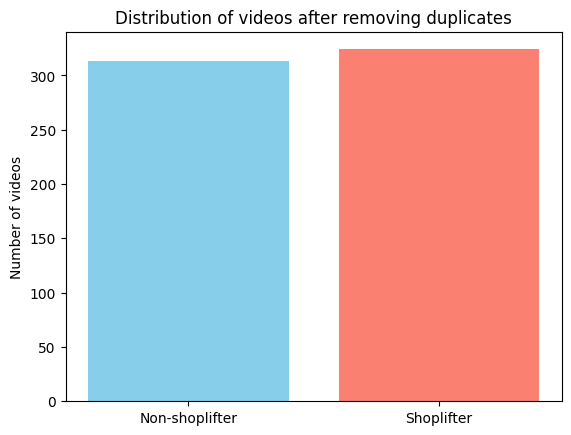

In [ ]:
import matplotlib.pyplot as plt
plt.bar(['Non-shoplifter', 'Shoplifter'], [num_non_shoplifter, num_shoplifter], color=['skyblue', 'salmon'])
plt.title("Distribution of videos after removing duplicates")
plt.ylabel("Number of videos")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

train_videos, val_videos, train_labels, val_labels = train_test_split(
    video_paths,
    labels,
    test_size=0.20,
    stratify=labels,
    random_state=42
)

train_videos, test_videos, train_labels, test_labels = train_test_split(
    train_videos,
    train_labels,
    test_size=0.15,
    stratify=train_labels,
    random_state=42
)

print("Train:", len(train_videos))
print("Validation:", len(val_videos))
print("Test:", len(test_videos))

Train: 432
Validation: 128
Test: 77


In [ ]:
import cv2
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [ ]:
IMG_SIZE = 224
MAX_FRAMES = 16


In [ ]:
#  Data Augmentation

datagen = ImageDataGenerator(
    rotation_range=3,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.7,1.3]
)

In [ ]:
def augment_video(frames):
    augmented = []
    for frame in frames:
        frame = datagen.random_transform(frame)
        augmented.append(frame)
    return np.array(augmented)

In [ ]:
# Extract frames
def extract_frames(video_path):
    cap = cv2.VideoCapture(video_path)
    frames = []
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    step = max(total_frames // MAX_FRAMES, 1)
    count = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        if count % step == 0:
            frame = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
            frames.append(frame)
        count += 1
        if len(frames) == MAX_FRAMES:
            break
    cap.release()
    while len(frames) < MAX_FRAMES:
        frames.append(np.zeros((IMG_SIZE, IMG_SIZE, 3)))
    return np.array(frames)

In [ ]:
#Video Data Generator

class VideoDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, video_paths, labels, batch_size=8, augment=False, shuffle=True):
        self.video_paths = video_paths
        self.labels = labels
        self.batch_size = batch_size
        self.augment = augment
        self.shuffle = shuffle
        self.indexes = np.arange(len(self.video_paths))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.video_paths) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index*self.batch_size:(index+1)*self.batch_size]
        X = []
        y = []
        for i in batch_indexes:
            frames = extract_frames(self.video_paths[i])
            if self.augment:
                frames = augment_video(frames)
            frames = frames / 255.0
            X.append(frames)
            y.append(self.labels[i])
        return np.array(X), np.array(y)

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indexes)

In [ ]:
# generators

train_gen = VideoDataGenerator(train_videos, train_labels, batch_size=8, augment=True)


In [ ]:
val_gen = VideoDataGenerator(val_videos, val_labels, batch_size=8, augment=False)


In [ ]:
test_gen = VideoDataGenerator(test_videos, test_labels, batch_size=8, augment=False)

In [ ]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights = dict(enumerate(class_weights))
print("Class weights:", class_weights)

Class weights: {0: np.float64(1.0188679245283019), 1: np.float64(0.9818181818181818)}


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv3D, MaxPooling3D, Dense, Dropout, BatchNormalization, GlobalAveragePooling3D
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, precision_score, recall_score
import matplotlib.pyplot as plt
import numpy as np

# 3D CNN Model

In [ ]:
model = Sequential([
    Conv3D(16, (3,3,3), activation='relu', input_shape=(16,224,224,3), padding='same'),
    MaxPooling3D((2,2,2)),
    BatchNormalization(),

    Conv3D(32, (3,3,3), activation='relu', padding='same'),
    MaxPooling3D((2,2,2)),
    BatchNormalization(),

    Conv3D(64, (3,3,3), activation='relu', padding='same'),
    MaxPooling3D((2,2,2)),
    BatchNormalization(),

    GlobalAveragePooling3D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='binary_crossentropy',
              metrics=['accuracy'])


In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv3d_6 (Conv3D)               │ (None, 16, 224, 224,   │         1,312 │
│                                 │ 16)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_6 (MaxPooling3D)  │ (None, 8, 112, 112,    │             0 │
│                                 │ 16)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 8, 112, 112,    │            64 │
│ (BatchNormalization)            │ 16)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_7 (Conv3D)               │ (None, 8, 112, 112,    │        13,856 │
│                                 │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_7 (MaxPooling3D)  │ (None, 4, 56, 56, 32)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 4, 56, 56, 32)  │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_8 (Conv3D)               │ (None, 4, 56, 56, 64)  │        55,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_8 (MaxPooling3D)  │ (None, 2, 28, 28, 64)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 2, 28, 28, 64)  │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling3d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling3D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,425 (310.25 KB)

 Trainable params: 79,201 (309.38 KB)

 Non-trainable params: 224 (896.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)

In [ ]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 290s 5s/step - accuracy: 0.4887 - loss: 0.6964 - val_accuracy: 0.5078 - val_loss: 0.6994 - learning_rate: 1.0000e-04
Epoch 2/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 269s 5s/step - accuracy: 0.5552 - loss: 0.6902 - val_accuracy: 0.5078 - val_loss: 0.7068 - learning_rate: 1.0000e-04
Epoch 3/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 268s 5s/step - accuracy: 0.5262 - loss: 0.6978 - val_accuracy: 0.5078 - val_loss: 0.7193 - learning_rate: 1.0000e-04
Epoch 4/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 268s 5s/step - accuracy: 0.5087 - loss: 0.6903 - val_accuracy: 0.5078 - val_loss: 0.6928 - learning_rate: 1.0000e-04
Epoch 5/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 267s 5s/step - accuracy: 0.5233 - loss: 0.6873 - val_accuracy: 0.5078 - val_loss: 0.6933 - learning_rate: 1.0000e-04
Epoch 6/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 267s 5s/step - accuracy: 0.5582 - loss: 0.6820 - val_accuracy: 0.4922 - val_loss: 0.7190 - learning_rate: 1.0000e-04
Epoch 7/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 268s 5s/step - accuracy: 0.5711 

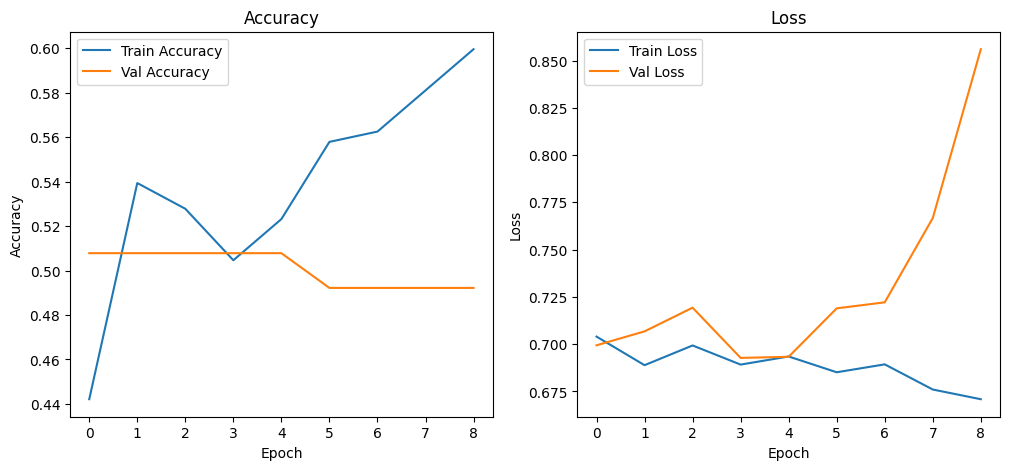

In [ ]:
#  رسم Accuracy و Loss

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
results = model.evaluate(test_gen)
print(f"Test Loss: {results[0]:.4f}, Test Accuracy: {results[1]:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 27s 3s/step - accuracy: 0.4829 - loss: 0.6938
Test Loss: 0.6921, Test Accuracy: 0.5065
